In [12]:
%load_ext autoreload
%autoreload 2

# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

from catrace.exp_collection import concatenate_df_from_db
all_dff = concatenate_df_from_db(dsconfig.processed_trace_dir, dsconfig.exp_list)

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


In [14]:
import os
import pandas as pd
save_dir = os.path.join(dsconfig.results_dir, 'persistency')

persistent_indices_df = pd.read_pickle(os.path.join(save_dir, 'persistent_indices.pkl'))
clustered_persistent_indices_df = pd.read_pickle(os.path.join(save_dir, 'clustered_persistent_indices.pkl'))
clustered_scaled_df = pd.read_pickle(os.path.join(save_dir, 'clustered_scaled_indices.pkl'))

Text(0, 0.5, 'Number of Neurons')

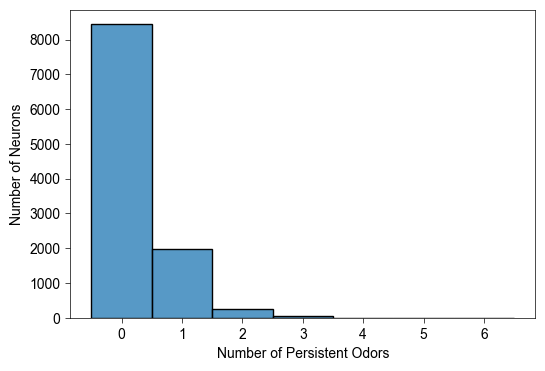

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Statistics of the persistency of neurons
odors = dsconfig.odors_stimuli
pers_index_threshold = 0.9
num_pers_odors = (persistent_indices_df > pers_index_threshold).T.sum()

# Plot histogram of num_pers_odors
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(num_pers_odors, bins=np.arange(-0.5, len(odors)+1.5, 1), ax=ax)
ax.set_xlabel('Number of Persistent Odors')
ax.set_ylabel('Number of Neurons')


In [16]:
# rename column 0 to 'num_pers_odors'
num_pers_odors = num_pers_odors.reset_index().rename(columns={0: 'num_pers_odors'})
num_pers_odors

,fish_id,condition,plane,neuron,neuron_id,num_pers_odors
0,2021-07-15-DpOBEM-N2_Dp,naive,0,4,3,0
1,2021-07-15-DpOBEM-N2_Dp,naive,0,12,8,0
2,2021-07-15-DpOBEM-N2_Dp,naive,0,24,19,0
3,2021-07-15-DpOBEM-N2_Dp,naive,0,35,30,0
4,2021-07-15-DpOBEM-N2_Dp,naive,0,44,39,0
...,...,...,...,...,...,...
10701,2021-11-26-DpOBEM-JH24_Dp,phe-trp,3,202,1530,0
10702,2021-11-26-DpOBEM-JH24_Dp,phe-trp,3,205,1533,0
10703,2021-11-26-DpOBEM-JH24_Dp,phe-trp,3,209,1536,0
10704,2021-11-26-DpOBEM-JH24_Dp,phe-trp,3,212,1539,1


In [17]:
# Count number of neurons per fish_id
# num_neurons_per_fish = clustered_persistent_indices_df.groupby('fish_id').size()
# num_neurons_per_fish

all_dff.columns
# Convert all_dff.columns to dataframe
all_dff_columns_df = pd.DataFrame(all_dff.columns.tolist(), columns=all_dff.columns.names)
all_dff_columns_df
num_neurons_per_fish = all_dff_columns_df.groupby('fish_id').size()
num_neurons_per_fish

fish_id
2021-02-05-DpOBEM-JH9_Dp     1588
2021-03-18-DpOBEM-JH10_Dp    1949
2021-03-19-DpOBEM-JH10_Dp    1873
2021-04-02-DpOBEM-JH11_Dp    1656
2021-04-03-DpOBEM-JH11_Dp    1222
2021-05-01-DpOBEM-JH13_Dp     826
2021-05-22-DpOBEM-JH14_Dp     735
2021-07-15-DpOBEM-N2_Dp      1299
2021-07-16-DpOBEM-N3_Dp      1398
2021-07-30-DpOBEM-JH17_Dp    1325
2021-07-31-DpOBEM-JH17_Dp    1238
2021-09-02-DpOBEM-JH18_Dp    1469
2021-09-03-DpOBEM-JH18_Dp    1031
2021-09-04-DpOBEM-JH18_Dp    1350
2021-09-15-DpOBEM-JH20_Dp     913
2021-09-17-DpOBEM-JH20_Dp    1453
2021-09-18-DpOBEM-JH20_Dp    1164
2021-09-29-DpOBEM-JH21_Dp    1529
2021-10-01-DpOBEM-JH21_Dp    1747
2021-10-02-DpOBEM-JH21_Dp    1666
2021-10-14-DpOBEM-JH22_Dp    1658
2021-11-10-DpOBEM-JH23_Dp    1396
2021-11-11-DpOBEM-JH23_Dp    1019
2021-11-14-DpOBEM-JH23_Dp    1072
2021-11-24-DpOBEM-JH24_Dp    1306
2021-11-26-DpOBEM-JH24_Dp    1541
2021-11-27-DpOBEM-JH24_Dp    1426
2021-12-10-DpOBEM-N4_Dp      1407
2021-12-31-DpOBEM-N7_Dp      1368
2022-0

In [18]:

# For each fish_id, groupby num_pers_odors and count the number of neurons in each group
# Count neurons per num_pers_odors within each fish_id
neuron_count_per_fish = (
    num_pers_odors.groupby(['fish_id', 'condition', 'num_pers_odors'])
      .size()
      .reset_index(name='neuron_count')
)


# Normalize the neuron count by the total number of neurons in each fish_id
neuron_count_per_fish = neuron_count_per_fish.merge(num_neurons_per_fish.rename('total_neurons'), on='fish_id')
neuron_count_per_fish['normalized_count'] = neuron_count_per_fish['neuron_count'] / neuron_count_per_fish['total_neurons']

neuron_count_per_fish

,fish_id,condition,num_pers_odors,neuron_count,total_neurons,normalized_count
0,2021-02-05-DpOBEM-JH9_Dp,phe-arg,0,251,1588,0.158060
1,2021-02-05-DpOBEM-JH9_Dp,phe-arg,1,51,1588,0.032116
2,2021-02-05-DpOBEM-JH9_Dp,phe-arg,2,10,1588,0.006297
3,2021-02-05-DpOBEM-JH9_Dp,phe-arg,3,2,1588,0.001259
4,2021-03-18-DpOBEM-JH10_Dp,phe-arg,0,405,1949,0.207799
...,...,...,...,...,...,...
109,2022-02-13-DpOBEM-N10_Dp,naive,2,18,1889,0.009529
110,2022-02-13-DpOBEM-N10_Dp,naive,3,1,1889,0.000529
111,2022-02-20-DpOBEM-N11_Dp,naive,0,154,1698,0.090695
112,2022-02-20-DpOBEM-N11_Dp,naive,1,22,1698,0.012956


In [19]:
neuron_count_per_fish

,fish_id,condition,num_pers_odors,neuron_count,total_neurons,normalized_count
0,2021-02-05-DpOBEM-JH9_Dp,phe-arg,0,251,1588,0.158060
1,2021-02-05-DpOBEM-JH9_Dp,phe-arg,1,51,1588,0.032116
2,2021-02-05-DpOBEM-JH9_Dp,phe-arg,2,10,1588,0.006297
3,2021-02-05-DpOBEM-JH9_Dp,phe-arg,3,2,1588,0.001259
4,2021-03-18-DpOBEM-JH10_Dp,phe-arg,0,405,1949,0.207799
...,...,...,...,...,...,...
109,2022-02-13-DpOBEM-N10_Dp,naive,2,18,1889,0.009529
110,2022-02-13-DpOBEM-N10_Dp,naive,3,1,1889,0.000529
111,2022-02-20-DpOBEM-N11_Dp,naive,0,154,1698,0.090695
112,2022-02-20-DpOBEM-N11_Dp,naive,1,22,1698,0.012956


In [20]:
neuron_count_per_fish

,fish_id,condition,num_pers_odors,neuron_count,total_neurons,normalized_count
0,2021-02-05-DpOBEM-JH9_Dp,phe-arg,0,251,1588,0.158060
1,2021-02-05-DpOBEM-JH9_Dp,phe-arg,1,51,1588,0.032116
2,2021-02-05-DpOBEM-JH9_Dp,phe-arg,2,10,1588,0.006297
3,2021-02-05-DpOBEM-JH9_Dp,phe-arg,3,2,1588,0.001259
4,2021-03-18-DpOBEM-JH10_Dp,phe-arg,0,405,1949,0.207799
...,...,...,...,...,...,...
109,2022-02-13-DpOBEM-N10_Dp,naive,2,18,1889,0.009529
110,2022-02-13-DpOBEM-N10_Dp,naive,3,1,1889,0.000529
111,2022-02-20-DpOBEM-N11_Dp,naive,0,154,1698,0.090695
112,2022-02-20-DpOBEM-N11_Dp,naive,1,22,1698,0.012956


Text(0, 0.5, 'Normalized Count of Neurons')

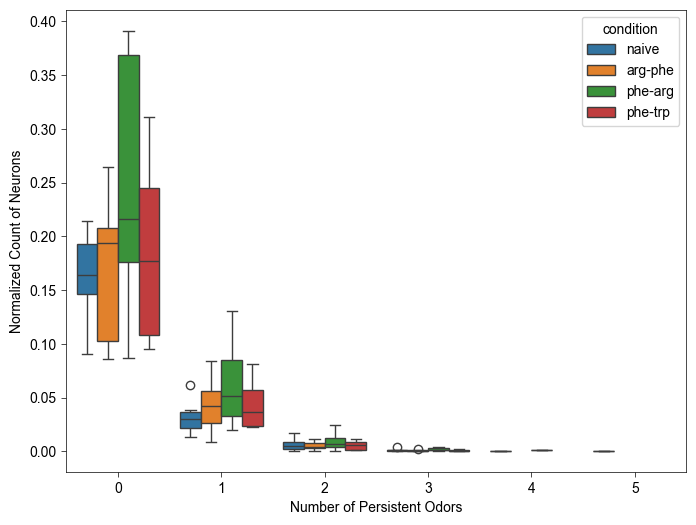

In [21]:
# Plot boxplot of 'normalized_count' with 'num_pers_odors' on x-axis and 'condition' as hue
fig, ax = plt.subplots(figsize=(8, 6))
# Order by condition
conditions = dsconfig.conditions
neuron_count_per_fish['condition'] = pd.Categorical(neuron_count_per_fish['condition'], categories=conditions, ordered=True)
sns.boxplot(data=neuron_count_per_fish, x='num_pers_odors', y='normalized_count', hue='condition', ax=ax)
ax.set_xlabel('Number of Persistent Odors')
ax.set_ylabel('Normalized Count of Neurons')

C:\Users\hubob\AppData\Local\Temp\ipykernel_21616\2089692062.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_neuron_count_per_fish['normalized_count'] = sub_neuron_count_per_fish['normalized_count'] * 100


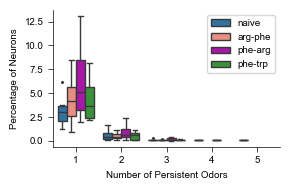

In [22]:
color_dict = {'naive': 'tab:blue', 
              'arg-phe': 'salmon',
              'phe-arg': 'm',
              'phe-trp': 'tab:green',
}
# Plot boxplot of 'normalized_count' with 'num_pers_odors' on x-axis and 'condition' as hue
fig, ax = plt.subplots(figsize=(3, 2))
# Order by condition
conditions = dsconfig.conditions
neuron_count_per_fish['condition'] = pd.Categorical(neuron_count_per_fish['condition'], categories=conditions, ordered=True)
# Outlier points markersize = 1.2
# Only plot from 1 onward
sub_neuron_count_per_fish = neuron_count_per_fish[neuron_count_per_fish['num_pers_odors'] > 0]
sub_neuron_count_per_fish['normalized_count'] = sub_neuron_count_per_fish['normalized_count'] * 100
sns.boxplot(data=sub_neuron_count_per_fish, x='num_pers_odors', y='normalized_count', hue='condition', ax=ax, showfliers=True, flierprops={'markersize': 1.2}, palette=color_dict)
ax.set_xlabel('Number of Persistent Odors', fontsize=7)
ax.set_ylabel('Percentage of Neurons', fontsize=7)
# Tick label fontsize
ax.tick_params(axis='both', which='major', labelsize=7)
# Put legend outside the plot
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=7)
sns.despine()
plt.tight_layout()
from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
paper_fig_dir = os.path.join(paper_fig_root_dir, 'juvenile/offset_response/persistent_neurons/')
os.makedirs(paper_fig_dir, exist_ok=True)

fig_name = f'percentage_of_persistent_neurons_per_condition'
#save_figure_for_paper(fig, fig_name, paper_fig_dir)

C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


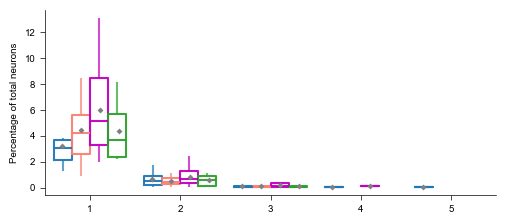

In [24]:
from catrace.visualize import plot_boxplot_with_significance_multi_odor_cond
color_dict = {'naive': 'tab:blue', 
              'arg-phe': 'salmon',
              'phe-arg': 'm',
              'phe-trp': 'tab:green',
}
hue_colors = [color_dict[cond] for cond in conditions]
fig, ax = plot_boxplot_with_significance_multi_odor_cond(
    sub_neuron_count_per_fish,
    yname='normalized_count',
    test_results=None,
    odor_name='num_pers_odors',
    condition_name='condition',
    do_plot_strip=False,
    ylabel='Percentage of total neurons',
    figsize=(6.5, 2.5),
    label_fontsize=7,
    hue_colors=hue_colors,
    mean_hue_colors=['gray', 'gray', 'gray', 'gray'],
    box_width=0.8,
    mean_dodge=0.63,
    mean_marker_size=1,
    box_linewidth=1.5
)
# remove legend
ax.legend().remove()

fig_name = f'percentage_of_persistent_neurons_per_condition'
save_figure_for_paper(fig, fig_name, paper_fig_dir)

In [34]:
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure04')
os.makedirs(save_dir, exist_ok=True)

sub_neuron_count_per_fish.to_csv(os.path.join(save_dir, 'extended_figure04i_percentage_of_persistent_neurons_per_condition.csv'))


In [25]:
# Display all rows
neuron_count_per_fish

,fish_id,condition,num_pers_odors,neuron_count,total_neurons,normalized_count
0,2021-02-05-DpOBEM-JH9_Dp,phe-arg,0,251,1588,0.158060
1,2021-02-05-DpOBEM-JH9_Dp,phe-arg,1,51,1588,0.032116
2,2021-02-05-DpOBEM-JH9_Dp,phe-arg,2,10,1588,0.006297
3,2021-02-05-DpOBEM-JH9_Dp,phe-arg,3,2,1588,0.001259
4,2021-03-18-DpOBEM-JH10_Dp,phe-arg,0,405,1949,0.207799
...,...,...,...,...,...,...
109,2022-02-13-DpOBEM-N10_Dp,naive,2,18,1889,0.009529
110,2022-02-13-DpOBEM-N10_Dp,naive,3,1,1889,0.000529
111,2022-02-20-DpOBEM-N11_Dp,naive,0,154,1698,0.090695
112,2022-02-20-DpOBEM-N11_Dp,naive,1,22,1698,0.012956


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

accdf = neuron_count_per_fish
orig_metric_name = 'normalized_count'

# Suppose your dataframe is called df
# Group and compute mean + std
summary = accdf.groupby(['num_pers_odors', 'condition']).agg(
    mean=(orig_metric_name, 'mean'),
    std=(orig_metric_name, 'std'),
    sem=(orig_metric_name, 'sem'),
).reset_index()
summary

# Fill NaN with 0
#summary = summary.fillna(0)

C:\Users\hubob\AppData\Local\Temp\ipykernel_21616\3711390198.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = accdf.groupby(['num_pers_odors', 'condition']).agg(


,num_pers_odors,condition,mean,std,sem
0,0,naive,0.162882,0.044259,0.018069
1,0,arg-phe,0.173035,0.065643,0.021881
2,0,phe-arg,0.254718,0.111012,0.035105
3,0,phe-trp,0.185590,0.091962,0.037543
4,1,naive,0.032136,0.017204,0.007023
5,1,arg-phe,0.043955,0.022871,0.007624
6,1,phe-arg,0.059621,0.035725,0.011297
7,1,phe-trp,0.043295,0.024263,0.009905
8,2,naive,0.006349,0.006144,0.002508
9,2,arg-phe,0.004775,0.003472,0.001157


In [27]:
# Remove rows in summary where num_pers_odors is 0
summary = summary[summary['num_pers_odors'] > 0]
summary

,num_pers_odors,condition,mean,std,sem
4,1,naive,0.032136,0.017204,0.007023
5,1,arg-phe,0.043955,0.022871,0.007624
6,1,phe-arg,0.059621,0.035725,0.011297
7,1,phe-trp,0.043295,0.024263,0.009905
8,2,naive,0.006349,0.006144,0.002508
9,2,arg-phe,0.004775,0.003472,0.001157
10,2,phe-arg,0.008462,0.007735,0.002446
11,2,phe-trp,0.005471,0.004628,0.002070
12,3,naive,0.001392,0.001445,0.000722
13,3,arg-phe,0.001102,0.000877,0.000438


    Contrast        A        B  Paired  Parametric         T        dof  \
0  condition  arg-phe    naive   False        True  0.357813  12.976237   
1  condition  arg-phe  phe-arg   False        True -1.974630  14.832884   
2  condition  arg-phe  phe-trp   False        True -0.288907   8.370123   
3  condition    naive  phe-arg   False        True -2.326016  12.785118   
4  condition    naive  phe-trp   False        True -0.545012  10.000000   
5  condition  phe-arg  phe-trp   False        True  1.344930  12.329306   

  alternative     p_unc   BF10    hedges  
0   two-sided  0.726236  0.461  0.163768  
1   two-sided  0.067228   1.45 -0.843721  
2   two-sided  0.779679  0.455 -0.153771  
3   two-sided  0.037139  2.183 -0.935088  
4   two-sided  0.597690  0.514 -0.290458  
5   two-sided  0.202866  0.781  0.624790  
num_neurons: 0, condition: arg-phe, pvalue: 1.0
num_neurons: 0, condition: phe-arg, pvalue: 0.11141597942325918
num_neurons: 0, condition: phe-trp, pvalue: 1.0
    Contrast 

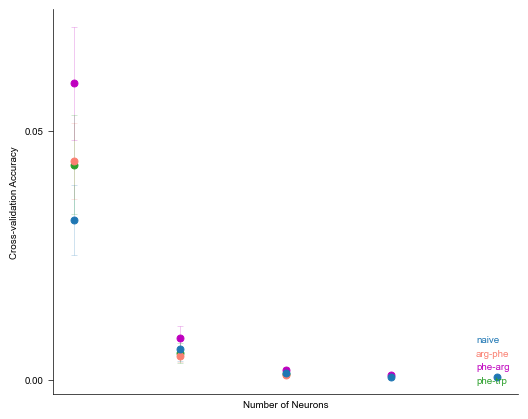

In [28]:
from matplotlib.ticker import MultipleLocator

plot_mode = 'notebook' # 'paper'

if plot_mode == 'paper':
    figsize = (1.9, 1.8)
    markersize = 2
    linewidth = 0.5
else:
    figsize = (6, 5)
    markersize = 5
    linewidth = 1

color_dict = {'naive': 'tab:blue', 
              'arg-phe': 'salmon',
              'phe-arg': 'm',
              'phe-trp': 'tab:green',
}
fig, ax = plt.subplots(figsize=figsize)

xname = 'num_pers_odors'
yname = 'normalized_count'

# Add error bars manually for std
for condition in summary['condition'].unique():
    subset = summary[summary['condition'] == condition]
    ax.errorbar(
        subset[xname],
        subset['mean'],
        yerr=subset['sem'],  # use standard error of the mean #['std_cv_acc'], sem
        fmt='none', capsize=2,
        color=color_dict[condition],
        linewidth=0.5,
        # horizontal bar line width
        capthick=0.5,
        alpha=0.3
    )
# Plot with seaborn
sns.lineplot(
    data=summary,
    x=xname,
    y='mean',
    hue='condition',
    marker='o',
    markersize=markersize,
    palette=color_dict,
    hue_order=reversed(dsconfig.conditions),
    ax=ax,
    linewidth=0,          # no connecting line
    alpha=1,              # markers opaque
    #markerfacecolor='none',
    mec=None,
    mew=0.7,
)

sns.despine(ax=ax)


import matplotlib.lines as mlines


# Get existing legend entries from seaborn
handles, labels = ax.get_legend_handles_labels()

# Pick your desired order (an ordered list of label names)
desired_order = ["naive", "arg-phe", "phe-arg", "phe-trp"]

# Reorder handles and labels
ordered_handles = []
ordered_labels = []

for name in desired_order:
    idx = labels.index(name)        # find the index for that label
    ordered_handles.append(handles[idx])
    ordered_labels.append(labels[idx])

# Create invisible handles (no line markers in legend)
dummy_handles = [mlines.Line2D([], [], linestyle='none') for _ in ordered_handles]

# Build the legend
legend = ax.legend(
    dummy_handles,
    ordered_labels,
    title=None,
    frameon=False,
    fontsize=7,
    loc='lower right'
)

# Color the text to match the actual line colors
for text_obj, real_handle in zip(legend.get_texts(), ordered_handles):
    try:
        color = real_handle.get_color()
    except AttributeError:
        color = real_handle.get_facecolor()
    text_obj.set_color(color)



# Set fontsize for x and y tick labels to 7
ax.tick_params(axis='both', which='both', labelsize=7)
# use multilocator to set x label interval as 100
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.set_ylabel("Cross-validation Accuracy", fontsize=7)
ax.set_xlabel("Number of Neurons", fontsize=7)
#ax.set_xlim((190, 750))



# Statistics
test_results_list = []
xvalue_list = sorted(num_pers_odors['num_pers_odors'].unique())

df_for_stat = neuron_count_per_fish

xvalue_list = [0, 1, 2, 3]
for num_neurons in xvalue_list:
    #subdf = all_lda_df.xs(num_neurons, level='sample_size')
    subdf = df_for_stat[df_for_stat['num_pers_odors'] == num_neurons].set_index('condition')['normalized_count']
    # Convert subdf, which is a Series, to a DataFrame that contains one column
    subdf = subdf.to_frame()

    # Rename first column to 'mean_lda_cv_score'
    yname = yname

    from catrace.stats import apply_test_by_cond
    from catrace.visualize import pvalue_to_marker
    test_results = apply_test_by_cond(
        subdf,
        yname,
        naive_name='naive',
        cond_name='condition',
        test_type='kruskal',
        return_all_pairs=False,
        padjust='bonf',
    )
    test_results_list.append(test_results) 

    for idx, condition in enumerate(dsconfig.conditions):
        if condition == 'naive':
            continue
        pvalue = test_results['Dunn_naive']['p_values'][condition]
        print(f'num_neurons: {num_neurons}, condition: {condition}, pvalue: {pvalue}')
        marker, xoffset = pvalue_to_marker(pvalue)
        if marker != 'n.s.':
            yoffset = -0.01 * idx
            if num_neurons == 25:
                yoffset -= 0.02
            # Put the marker to x=num_neurons, y=1
            ax.text(num_neurons + xoffset, 0.96+yoffset, marker, fontsize=6, ha='center', va='center', color=color_dict[condition])


# import os
# fig_dir = f'../figures/{dataset_name}/{window_name}/lda/'
# os.makedirs(fig_dir, exist_ok=True)


# # save figure
# fig.savefig(pjoin(fig_dir, f'lda_n_curve_odor_pair_{odor_group_name}.pdf'), bbox_inches='tight')




In [29]:
# Statistics of normalized_count
yes_pers_normalized_count = neuron_count_per_fish[neuron_count_per_fish['num_pers_odors'] > 0].groupby(['fish_id', 'condition'], observed=True)['normalized_count'].sum()
yes_pers_normalized_count
print(yes_pers_normalized_count.shape)
# Print mean and std of yes_pers_normalized_count
print(f"Mean of normalized count of persistent neurons (num_pers_odors > 0): {yes_pers_normalized_count.mean():.4f}")
print(f"Std of normalized count of persistent neurons (num_pers_odors > 0): {yes_pers_normalized_count.std():.4f}")
yes_pers_normalized_count_df = yes_pers_normalized_count.reset_index()
yes_pers_normalized_count_df

(31,)
Mean of normalized count of persistent neurons (num_pers_odors > 0): 0.0538
Std of normalized count of persistent neurons (num_pers_odors > 0): 0.0342


,fish_id,condition,normalized_count
0,2021-02-05-DpOBEM-JH9_Dp,phe-arg,0.039673
1,2021-03-18-DpOBEM-JH10_Dp,phe-arg,0.063622
2,2021-03-19-DpOBEM-JH10_Dp,phe-arg,0.114255
3,2021-04-02-DpOBEM-JH11_Dp,phe-arg,0.020531
4,2021-04-03-DpOBEM-JH11_Dp,phe-arg,0.060556
5,2021-05-01-DpOBEM-JH13_Dp,phe-arg,0.112591
6,2021-05-22-DpOBEM-JH14_Dp,phe-arg,0.160544
7,2021-07-15-DpOBEM-N2_Dp,naive,0.021555
8,2021-07-16-DpOBEM-N3_Dp,naive,0.040057
9,2021-07-30-DpOBEM-JH17_Dp,arg-phe,0.027925


In [30]:
# Test whether naive and trained are different in normalized_count in yes_pers_normalized_count
# trained includes all conditions except naive
from scipy.stats import mannwhitneyu
naive_counts = yes_pers_normalized_count_df[yes_pers_normalized_count_df['condition'] == 'naive']['normalized_count']
trained_counts = yes_pers_normalized_count_df[yes_pers_normalized_count_df['condition'] != 'naive']['normalized_count']
stat, pvalue = mannwhitneyu(naive_counts, trained_counts, alternative='two-sided')
print(f'Mann-Whitney U test between naive and trained for normalized count of neurons with 1 persistent odor: U={stat}, p={pvalue:.4f}')

Mann-Whitney U test between naive and trained for normalized count of neurons with 1 persistent odor: U=53.0, p=0.2906


In [31]:
one_pers_normalized_count = neuron_count_per_fish[neuron_count_per_fish['num_pers_odors'] == 1]
one_pers_normalized_count

# Test whether naive and trained are different in normalized_count in one_pers_normalized_count
# trained includes all conditions except naive
from scipy.stats import mannwhitneyu
naive_counts = one_pers_normalized_count[one_pers_normalized_count['condition'] == 'naive']['normalized_count']
trained_counts = one_pers_normalized_count[one_pers_normalized_count['condition'] != 'naive']['normalized_count']
stat, pvalue = mannwhitneyu(naive_counts, trained_counts, alternative='two-sided')
print(f'Mann-Whitney U test between naive and trained for normalized count of neurons with 1 persistent odor: U={stat}, p={pvalue:.4f}')
# Also print mean and std and number of fish for naive and trained
print(f"Mean of normalized count for naive: {naive_counts.mean():.4f}")
print(f"Std of normalized count for naive: {naive_counts.std():.4f}")
print(f"Number of fish for naive: {naive_counts.shape[0]}")
print(f"Mean of normalized count for trained: {trained_counts.mean():.4f}")
print(f"Std of normalized count for trained: {trained_counts.std():.4f}")
print(f"Number of fish for trained: {trained_counts.shape[0]}")

Mann-Whitney U test between naive and trained for normalized count of neurons with 1 persistent odor: U=48.0, p=0.1904
Mean of normalized count for naive: 0.0321
Std of normalized count for naive: 0.0172
Number of fish for naive: 6
Mean of normalized count for trained: 0.0501
Std of normalized count for trained: 0.0290
Number of fish for trained: 25
